In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

In [ ]:
#loading the dataset
df=pd.read_csv('linear_regression_datasest.csv')
df.head()

,Feature_1,Feature_2,Target
0,18.727006,26.661964,75.032045
1,47.535715,58.771085,186.095787
2,36.599697,88.565125,200.512604
3,29.932924,75.900240,174.586253
4,7.800932,82.590503,132.746780


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  1000 non-null   float64
 1   Feature_2  1000 non-null   float64
 2   Target     1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [6]:
df.columns

Index(['Feature_1', 'Feature_2', 'Target'], dtype='object')

In [7]:
df.shape

(1000, 3)

In [10]:
df.describe()

,Feature_1,Feature_2,Target
count,1000.000000,1000.000000,1000.000000
mean,24.512828,55.631557,133.169216
std,14.606868,26.297090,49.845584
min,0.231601,10.289644,11.866554
25%,11.798663,31.696684,97.734249
50%,24.840369,56.686052,134.027666
75%,37.215979,78.441855,169.051039
max,49.985884,99.947235,255.915972


In [ ]:
#finding the null values
df.isnull().sum()

Feature_1    0
Feature_2    0
Target       0
dtype: int64

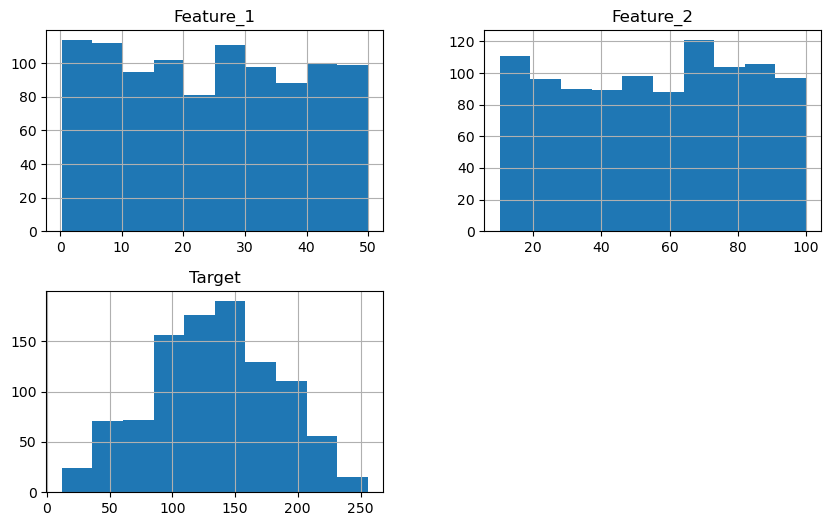

In [12]:
df.hist(figsize=(10,6))
plt.show()

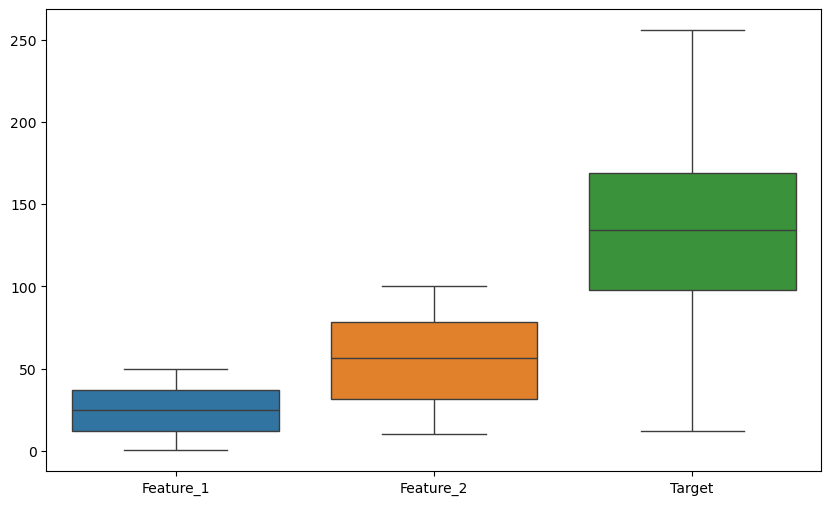

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

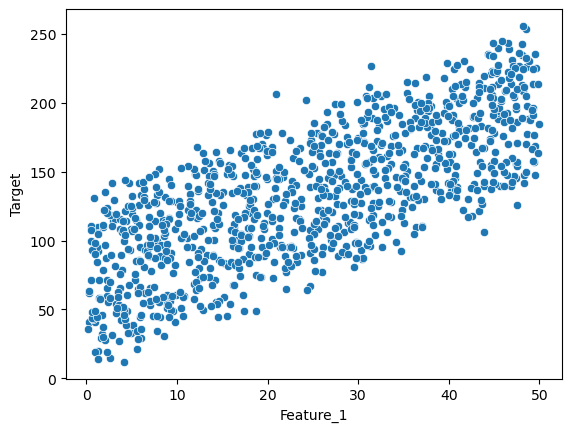

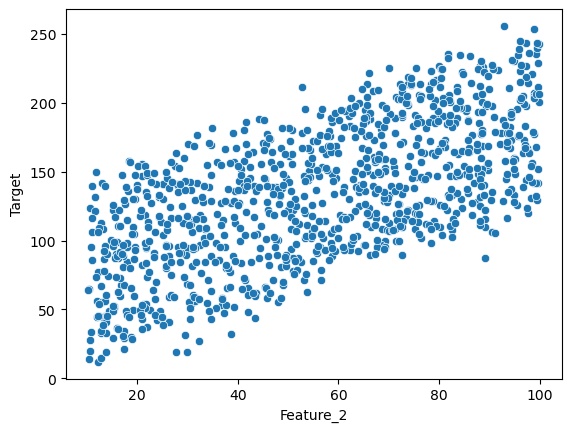

In [14]:
sns.scatterplot(x='Feature_1', y='Target', data=df)
plt.show()

sns.scatterplot(x='Feature_2', y='Target', data=df)
plt.show()

In [ ]:
#finding outliers using IQR method
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Feature_1: 0 outliers
Feature_2: 0 outliers
Target: 0 outliers


In [ ]:
#feature scaling using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[['Feature_1','Feature_2']])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=['Feature_1','Feature_2']
)

print(scaled_df.head())

   Feature_1  Feature_2
0  -0.396301  -1.102179
1   1.576957   0.119447
2   0.827893   1.252992
3   0.371251   0.771143
4  -1.144685   1.025681


In [ ]:
df['Interaction'] = df['Feature_1'] * df['Feature_2']

In [ ]:

df['Feature_1_sq'] = df['Feature_1'] ** 2
df['Feature_2_sq'] = df['Feature_2'] ** 2

In [19]:
print(df.head())

   Feature_1  Feature_2      Target  Interaction  Feature_1_sq  Feature_2_sq
0  18.727006  26.661964   75.032045   499.298751    350.700752    710.860303
1  47.535715  58.771085  186.095787  2793.725578   2259.644231   3454.040463
2  36.599697  88.565125  200.512604  3241.456756   1339.537827   7843.781407
3  29.932924  75.900240  174.586253  2271.916125    895.979952   5760.846398
4   7.800932  82.590503  132.746780   644.282902     60.854540   6821.191237


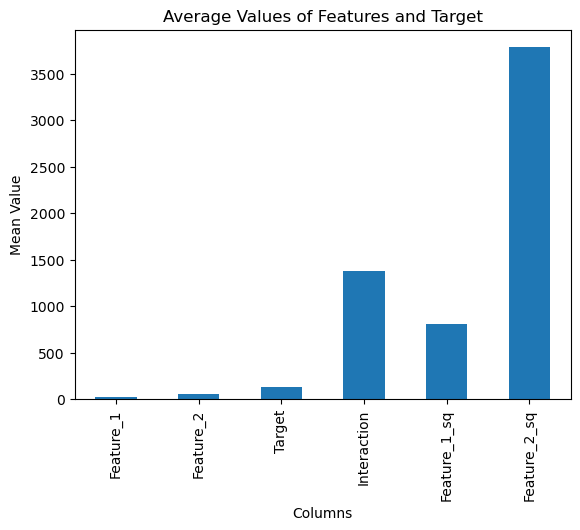

In [ ]:
#separate the features and target variable
df.mean().plot(kind='bar')

plt.title("Average Values of Features and Target")
plt.xlabel("Columns")
plt.ylabel("Mean Value")
plt.show()

In [ ]:
#separate the features and target variable
X = df[['Feature_1', 'Feature_2']]
y = df['Target']

print("Input Features:")
print(X.head())

print("Target:")
print(y.head())

Input Features:
   Feature_1  Feature_2
0  18.727006  26.661964
1  47.535715  58.771085
2  36.599697  88.565125
3  29.932924  75.900240
4   7.800932  82.590503
Target:
0     75.032045
1    186.095787
2    200.512604
3    174.586253
4    132.746780
Name: Target, dtype: float64


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 2)
Testing Data: (200, 2)


In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
#make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[165.30267131 140.22983517 164.04239661 126.21150297 148.06003385
 157.13456198  96.49042232 127.42460859 103.56485267 173.63283429]


In [28]:
new_data = [[5, 10]]

prediction = model.predict(new_data)

print("Predicted Target:", prediction)

Predicted Target: [29.35208287]


c:\Users\Brahm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 100.35222719050985


In [30]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.957500280399683


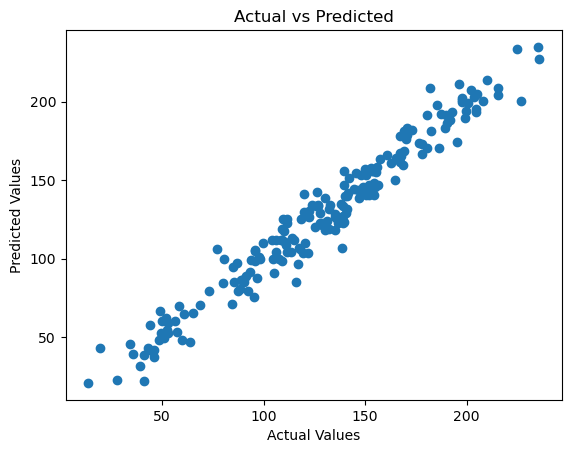

In [31]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

In [32]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.831195723111676
Coefficients: [2.50912402 1.19752671]
